In [2]:
# Core PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Torchvision
from torchvision import datasets, transforms, models

# Utilities
import numpy as np
import os
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

NUM_EPOCHS = 5
LEARNING_RATE = 1e-4

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')
# Your files in 'archive_2' will then be accessible at '/content/drive/MyDrive/archive_2'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DATASET_PATH = "/content/drive/MyDrive/archive (2)"

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [12]:
import os

# Verify if the DATASET_PATH exists
if not os.path.exists(DATASET_PATH):
    print(f"Error: The specified path does not exist: {DATASET_PATH}")
elif not os.path.isdir(DATASET_PATH):
    print(f"Error: The specified path is not a directory: {DATASET_PATH}")
else:
    print(f"Listing contents of {DATASET_PATH}:")
    for item in os.listdir(DATASET_PATH):
        print(item)


Listing contents of /content/drive/MyDrive/archive (2):
Grape
Potato
Peach
Bell Pepper
Corn (Maize)
Apple
Cherry


In [22]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [15]:
import os

# Path to one of the class folders to inspect its content
example_class_path = os.path.join(DATASET_PATH, 'Apple') # Assuming 'Apple' is one of the class folders

if os.path.exists(example_class_path) and os.path.isdir(example_class_path):
    print(f"Listing contents of {example_class_path}:")
    for item in os.listdir(example_class_path):
        print(item)
else:
    print(f"Error: The specified path does not exist or is not a directory: {example_class_path}")


Listing contents of /content/drive/MyDrive/archive (2)/Apple:
Train
Test
Val


In [23]:
import os
from PIL import Image # Import PIL

# Function to get all image paths and labels from the nested structure
def find_images_in_nested_structure(root_dir):
    images = []
    # Get class names from the direct subdirectories of root_dir (e.g., 'Apple', 'Potato')
    classes = sorted([d.name for d in os.scandir(root_dir) if d.is_dir()])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        # Iterate through 'Train', 'Test', 'Val' subdirectories within each PlantType class
        for split_dir_name in ['Train', 'Test', 'Val']:
            split_dir = os.path.join(class_dir, split_dir_name)
            if not os.path.isdir(split_dir):
                continue

            # This level contains disease/health condition folders (e.g., 'Healthy', 'Apple Scab')
            for disease_condition_name in os.listdir(split_dir):
                disease_condition_dir = os.path.join(split_dir, disease_condition_name)
                if not os.path.isdir(disease_condition_dir):
                    continue # Skip if it's not a directory

                # Debug print: Check content of one deepest level directory
                # Only print for the first few to avoid excessive output
                if len(images) == 0 and os.listdir(disease_condition_dir):
                    print(f"DEBUG: Found images in {disease_condition_dir}: {os.listdir(disease_condition_dir)[:5]}...")

                for img_name in os.listdir(disease_condition_dir):
                    img_path = os.path.join(disease_condition_dir, img_name)
                    # Check if it's a file and a common image extension
                    if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                        images.append((img_path, class_to_idx[class_name])) # Label with the PlantType
    return images, classes, class_to_idx

# Custom Dataset class to handle the collected paths and labels
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data = data # list of (image_path, label)
        self.transform = transform
        # Use PIL's Image.open for loading images
        self.loader = lambda path: Image.open(path).convert('RGB')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = self.loader(img_path)
        if self.transform:
            image = self.transform(image)
        return image, label

# Create the dataset using the custom loader
all_images_and_labels, classes, class_to_idx = find_images_in_nested_structure(DATASET_PATH)
dataset = CustomImageDataset(all_images_and_labels, transform=transform)

# Attach classes for consistency, though not strictly required for DataLoader
dataset.classes = classes
dataset.class_to_idx = class_to_idx

print("Classes:", dataset.classes)
print("Total images in dataset:", len(dataset))

DEBUG: Found images in /content/drive/MyDrive/archive (2)/Bell Pepper/Test/Healthy: ['47c2ad4e-4eca-4597-9784-c3d99444bf29___JR_HL 8450.JPG', '3be55250-5873-46f7-a55c-e16ec36a300d___JR_HL 8773.JPG', 'f7b9603d-96a2-4689-b86b-a1e1a53322f1___JR_HL 8385.JPG', '3e2945ba-7e94-4faa-9877-5133350e8733___JR_HL 7640_newPixel25.JPG', '3ede2904-b21a-4b6a-940b-062c21ff71fa___JR_HL 7613.JPG']...
Classes: ['Apple', 'Bell Pepper', 'Cherry', 'Corn (Maize)', 'Grape', 'Peach', 'Potato']
Total images in dataset: 2944


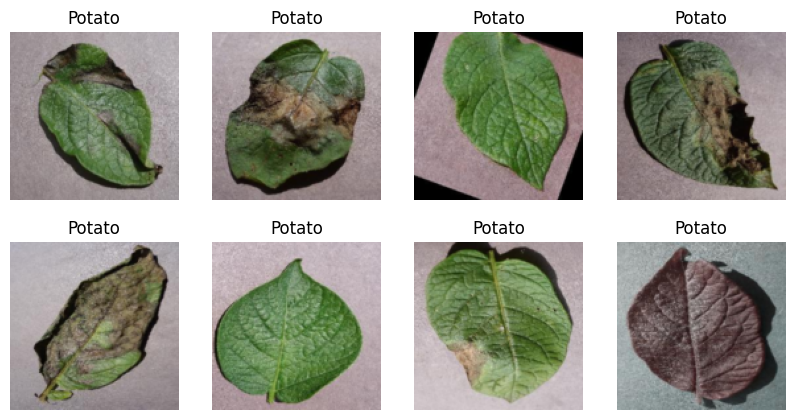

In [24]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,4, figsize=(10,5))

for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1,2,0)
    ax.imshow(img)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [25]:
def create_vgg16_model(num_classes):

    model = models.vgg16(pretrained=True)

    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[6] = nn.Linear(4096, num_classes)

    return model

In [26]:
num_classes = len(dataset.classes)

vgg16_model = create_vgg16_model(num_classes)

vgg16_model = vgg16_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.6MB/s]


In [27]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()
    running_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [28]:
def validate(model, loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, preds)

    return acc, preds, targets

In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    vgg16_model.parameters(),
    lr=LEARNING_RATE
)

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        vgg16_model,
        train_loader,
        criterion,
        optimizer
    )

    val_acc, _, _ = validate(vgg16_model, val_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)

100%|██████████| 148/148 [02:31<00:00,  1.02s/it]


Epoch 1/5
Train Loss: 0.1052158780942505
Validation Accuracy: 0.9966044142614601


100%|██████████| 148/148 [00:13<00:00, 10.75it/s]


Epoch 2/5
Train Loss: 0.016460428668957427
Validation Accuracy: 0.9949066213921901


100%|██████████| 148/148 [00:13<00:00, 10.68it/s]


Epoch 3/5
Train Loss: 0.005946764908574301
Validation Accuracy: 0.9949066213921901


100%|██████████| 148/148 [00:13<00:00, 10.62it/s]


Epoch 4/5
Train Loss: 0.017184837934895118
Validation Accuracy: 0.9966044142614601


100%|██████████| 148/148 [00:14<00:00, 10.50it/s]


Epoch 5/5
Train Loss: 0.002078321936597309
Validation Accuracy: 0.9966044142614601


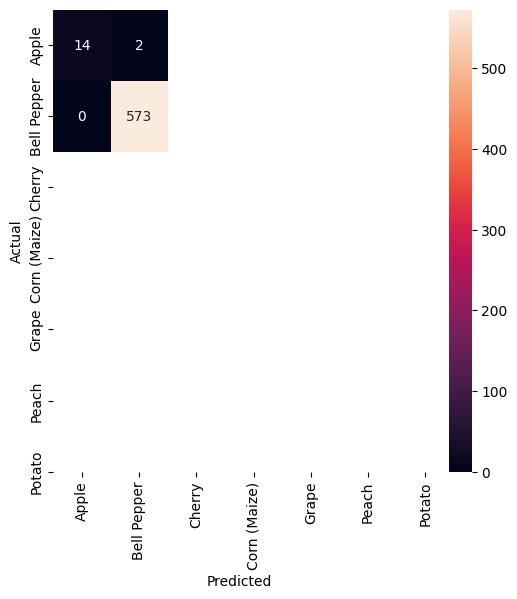

In [30]:
val_acc, preds, targets = validate(vgg16_model, val_loader)

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
torch.save(vgg16_model.state_dict(), "plant_disease_vgg16.pth")